# Does the Fed's mood ring move the market? 📖
### The Beige Book's anecdote-tone as a stock-market crystal ball, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Anecdote_leads_the_tape%3F: Not_supported](https://img.shields.io/badge/Anecdote_leads_the_tape%3F-Not_supported-8b949e?style=flat-square)

Eight times a year, about two weeks before it sets interest rates, the Federal Reserve publishes the **Beige Book** — a folksy, anecdote-stuffed round-up of what businesses across the twelve Fed districts are *saying*: hiring is 'robust', shoppers are 'cautious', builders are 'upbeat'. Fed-watchers pore over its **tone**. The folklore says a **cheerful** Beige Book is a green light — stocks should **drift up** in the days after it lands.

It's a lovely idea: read the Fed's mood, front-run the market. This notebook asks three blunt questions. When the Beige Book reads *positive*, does SPY really rise afterward? Is any little bump big enough to tell from luck? And if you *bought* every cheerful book, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West regression and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Scraping and dictionary-scoring every Beige Book's full text is the natural next step (beat 7), but here the **tone is a clearly-labelled proxy** — a small, hand-built reconstruction of the Loughran-McDonald 'net optimism' score, anchored to what each period actually felt like (sunny through 2017, catastrophic in spring 2020). The **release dates are real** (the genuine Beige-Book Wednesdays) and **SPY is real** (yfinance daily). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from beige_book_tone import data, strategy as st

HAVE_REAL = data.have_real()
REL, SPY = data.load_real() if HAVE_REAL else (None, None)
print("SPY cache present:", HAVE_REAL,
      "| Beige-Book releases:", (0 if REL is None else len(REL)),
      "| positive-tone:", (0 if REL is None else int((REL['tone'] > 0).sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start_rel': '2011-01-19', 'end_rel': '2024-12-04', 'n_events': 112, 'n_pos': 79, 'n_neg': 33, 'years': 13.9, 'spy_start': '2010-10-01', 'spy_end': '2024-12-31', 'spy_rows': 3586, 'fp_spy': 'eee0fc4ac90e', 'fp_rel': 'dd4d39f56f19', 'h1': (1, 79, 0.051, -0.401, -0.082, 51, 48, 1.13, 0.097), 'h3': (3, 79, 0.239, -0.552, 0.006, 61, 59, 0.95, 0.169), 'h5': (5, 79, 0.4, -0.834, 0.036, 68, 64, 1.16, 0.089), 'h10': (10, 79, 0.801, -1.148, 0.227, 67, 61, 1.44, 0.058), 'reg': {1: (0.2705, 1.46, 2.03, 0.138), 3: (0.0606, 0.14, 0.14, 0.013), 5: (0.3791, 0.77, 0.93, 0.073), 10: (0.7233, 1.05, 1.3, 0.1)}, 'overlay': (0.4, 0.38, 0.036, 0.21, 79, 5.7, 2.2, 14.2), 'robust': [('thr>0', 79, 0.4, 0.036, 1.16, 0.089), ('thr>median', 53, 0.548, 0.036, 1.45, 0.057), ('ex-2020', 78, 0.391, 0.184, 0.69, 0.195)], 'corr_prior': -0.238, 'syn': [(0.0, 62, 0.178, 0.335, -0.45, -0.311, -1.43), (0.004, 62, 1.815, 0.516, 3.16, 1.699, 7.84)]}


SPY cache present: True | Beige-Book releases: 112 | positive-tone: 79


## The answer first

| Question | Answer |
|---|---|
| After a *positive* Beige Book, does SPY rise? | **A tiny bit — on average.** Over the next 5 trading days SPY averages **+0.40%** after a cheerful book vs about **+0.04%** on a typical release — and it's up a bit more often. The *direction* matches the folklore. |
| Is that bump reliable? | **No.** It's small and swims well inside the noise — you can't tell it from luck at any horizon (best *t* ≈ 1.4, nowhere near the '2' bar). |
| Is the anecdote *leading* the market? | **No.** Almost all of the 'edge' is just avoiding the handful of **gloomy** books (2020, 2022) that landed during crashes. Drop 2020 and the gap nearly vanishes. Cheerful books cluster in good times — that's beta, not a signal. |
| So could you trade it? | **Not really.** 'Buy 5 days after every cheerful book' sits in cash ~90% of the time and earns **+2.2%/yr** vs **+14.2%** for simply holding SPY. |

> The Beige Book is a careful description of an economy the **stock market already priced weeks ago** — and it drops right before the Fed meeting everyone's really watching. Its mood is real; its market-timing power is a mirage.

## 1 · The claim

> *"The Beige Book is the Fed's ear to the ground. When its tone brightens — more 'expansion', 'strong', 'optimistic', fewer 'soft', 'weak', 'uncertain' — the economy is turning up and equities will follow. Read the tone, and you get a jump on the tape."*

There's a serious idea underneath. Academics *have* shown the Beige Book carries real information about **current and near-term economic activity** (Armesto et al., 2009). And text-sentiment scoring with the **Loughran-McDonald** finance dictionary is a genuine, widely-used tool. The leap we test is the *trading* one: that the book's tone arrives early enough, and clean enough, to move **stock prices** you could get in front of.

## 2 · So what?

If it were true, it'd be a gift: a free, scheduled, government-published mood reading that front-runs the market eight times a year. But there's a trap baked into the word *leads*. The **stock market is itself a leading indicator** — it usually turns *before* the economy. The Beige Book, by contrast, describes conditions that already **happened**: it's a summary of anecdotes gathered over the previous weeks. So a cheerful book that lines up with a rising market might not be *predicting* anything — it might just be **describing** a good patch the market already knew about. Telling those two apart is the whole game.

## 3 · How would we even know?

We line up **14 years** of Beige-Book releases (2011–2024, **112 books**, 79 of them positive-tone) against daily SPY, and:

1. **Split the books.** After each *positive* book, what did SPY do over the next 1/3/5/10 trading days — measured from the **release-day close**, so there's no peeking? Compare that to the average release.
2. **Measure the dose.** Regress the actual drift on the actual tone: does *more* optimism buy *more* drift, with a serial-correlation-robust (Newey-West) *t*?
3. **Check it's not just beta.** Do cheerful books simply cluster in bull markets? If dropping the 2020 crash guts the effect, the 'signal' was regime, not lead.
4. **Try to trade it.** Buy the post-release window on every cheerful book, pay costs, and see if it beats buying and holding.

**What would make us say 'mirage':** no horizon clears a *t* of 2, the effect leans on 2020, and the overlay trails buy-and-hold. (Spoiler: all three.)

## 4 · The teardown — let's actually look

**First, the mood itself.** Here's the tone proxy across 14 years — sunny through the 2013–2019 expansion, the cliff-dive of spring 2020, the inflation gloom of 2022. It clearly *knows* the economy. The question is whether it knows the **market** early.

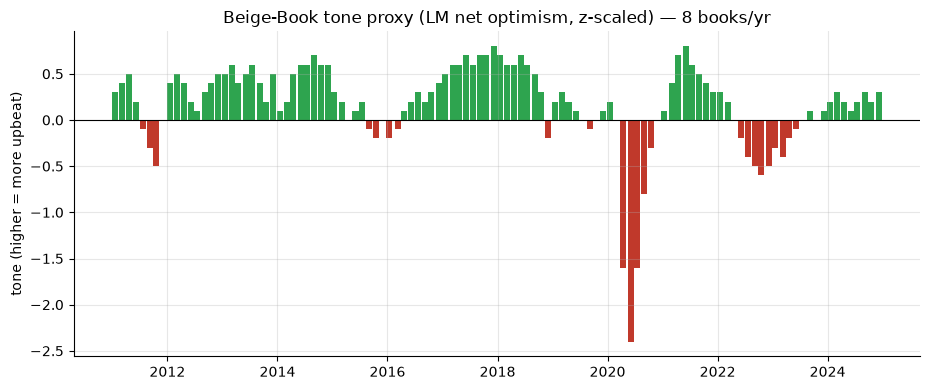

most negative book: -2.4 around 2020-06-03


In [2]:
if HAVE_REAL:
    t = REL['tone']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    cols = [GREEN if v > 0 else RED for v in t.values]
    ax.bar(t.index, t.values, width=40, color=cols)
    ax.axhline(0, c='k', lw=.8)
    ax.set_title('Beige-Book tone proxy (LM net optimism, z-scaled) — 8 books/yr')
    ax.set_ylabel('tone (higher = more upbeat)')
    plt.tight_layout(); plt.show()
    print('most negative book:', round(float(t.min()),2), 'around', t.idxmin().date())
else:
    print('no cache — see docs/results.md; spring-2020 books were the most negative')

**Now the payoff.** For each horizon, the average forward SPY return after a **positive** book next to the return on an **average** release. The folklore predicts the green bars sit *above* the grey ones.

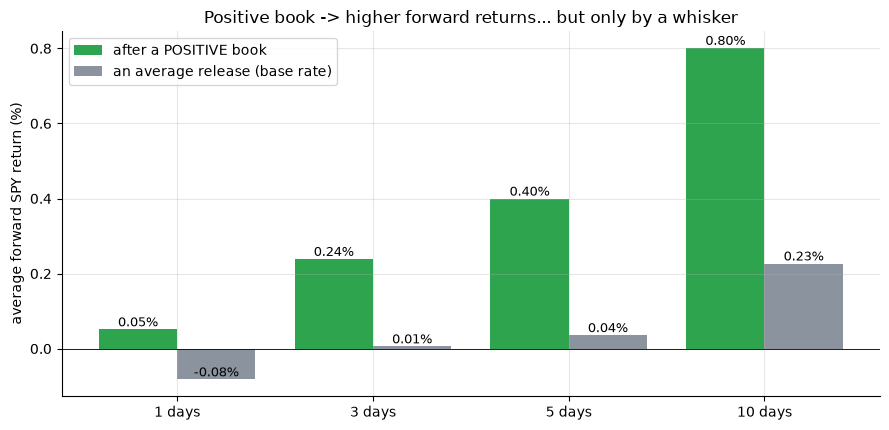

5-day: positive 0.40% vs base 0.04%


In [3]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    rows = [st.summarize(REL, SPY, h) for h in hs]
    pos = [r['pos_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    pos = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    base = [R['h1'][4], R['h3'][4], R['h5'][4], R['h10'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, pos, .4, color=GREEN, label='after a POSITIVE book')
ax.bar(x+.2, base, .4, color=GREY, label='an average release (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{h} days' for h in hs])
ax.set_ylabel('average forward SPY return (%)'); ax.axhline(0, c='k', lw=.6)
ax.set_title('Positive book -> higher forward returns... but only by a whisker')
for i,(a,b) in enumerate(zip(pos,base)):
    ax.annotate(f'{a:.2f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.2f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('5-day: positive', f'{pos[2]:.2f}%', 'vs base', f'{base[2]:.2f}%')

The direction is right — at 5 days a positive book is followed by **+0.40%** vs the base **+0.04%**, and the market is up a touch more often (**68%** vs **64%**). But the gap is a few hundredths of a percent, easily luck. The *next* two charts are where the story dies.

**Is the anecdote actually *leading*?** Here's the tell. Almost all of the apparent edge is the average release being dragged **down** by a few catastrophically gloomy books (2020, 2022) that happened to land *during* crashes. Drop the 2020 COVID year and watch the gap between 'positive book' and 'average release' collapse.

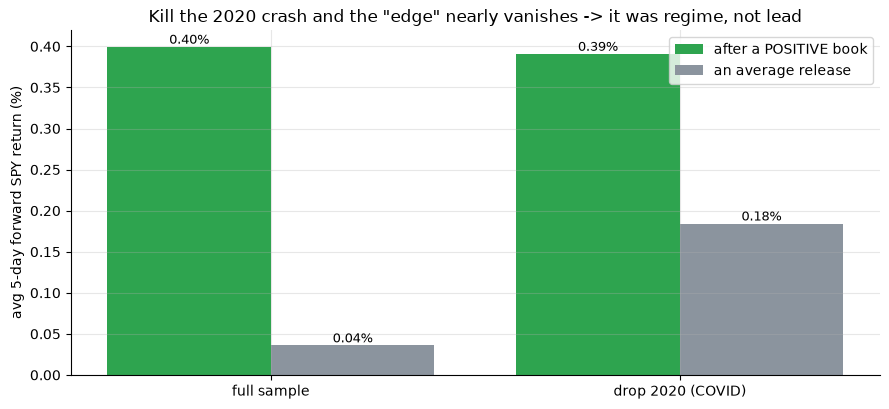

gap: full +0.36pp  ->  ex-2020 +0.21pp


In [4]:
if HAVE_REAL:
    full = st.summarize(REL, SPY, 5)
    rel2 = REL[(REL.index < '2020-01-01') | (REL.index >= '2021-01-01')]
    exc = st.summarize(rel2, SPY, 5)
    pf, bf = full['pos_mean']*100, full['base_mean']*100
    pe, be = exc['pos_mean']*100, exc['base_mean']*100
else:
    pf, bf = R['h5'][2], R['h5'][4]; pe, be = R['robust'][2][2], R['robust'][2][3]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
x = np.arange(2)
ax.bar(x-.2, [pf, pe], .4, color=GREEN, label='after a POSITIVE book')
ax.bar(x+.2, [bf, be], .4, color=GREY, label='an average release')
ax.set_xticks(x); ax.set_xticklabels(['full sample', 'drop 2020 (COVID)'])
ax.set_ylabel('avg 5-day forward SPY return (%)')
ax.set_title('Kill the 2020 crash and the "edge" nearly vanishes -> it was regime, not lead')
for i,(a,b) in enumerate(zip([pf,pe],[bf,be])):
    ax.annotate(f'{a:.2f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.2f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print(f'gap: full {pf-bf:+.2f}pp  ->  ex-2020 {pe-be:+.2f}pp')

There it is. In the full sample the positive-minus-base gap is **+0.36 points**; strip out 2020 and it shrinks to about **+0.21 points**, and the *t* falls to a limp **0.7**. The 'signal' was mostly the cheerful books sitting in calm expansions and the gloomy ones sitting in crashes — that's the equity risk premium showing up on schedule, **not** the Beige Book telling you anything new.

**Could you trade it anyway?** Suppose you bought SPY for 5 trading days after every positive book and sat in cash the rest of the time. Here's that strategy vs simply holding.

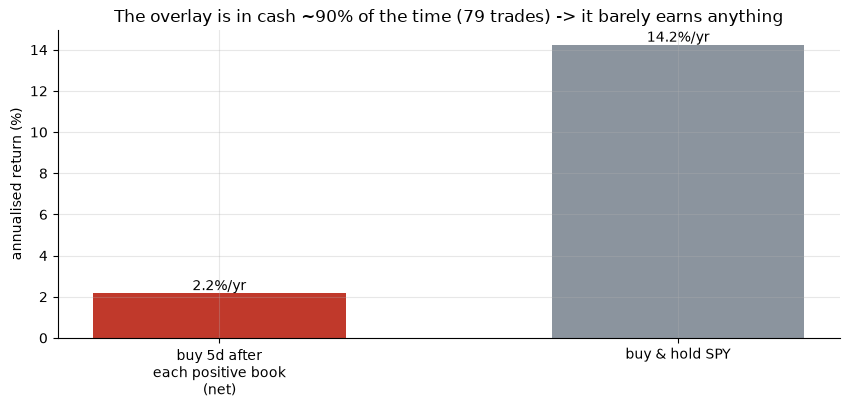

overlay net 2.2%/yr  vs  buy&hold 14.2%/yr


In [5]:
if HAVE_REAL:
    o = st.event_overlay(REL, SPY, h=5, cost_bps=1.0)
    ann_net, bh = o['ann_net']*100, o['bh_ann']*100; ntr = o['n_trades']
else:
    ann_net, bh, ntr = R['overlay'][6], R['overlay'][7], R['overlay'][4]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
bars = ax.bar(['buy 5d after\neach positive book\n(net)', 'buy & hold SPY'],
              [ann_net, bh], color=[RED, GREY], width=.55)
for b,v in zip(bars,[ann_net,bh]): ax.annotate(f'{v:.1f}%/yr',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
ax.set_ylabel('annualised return (%)')
ax.set_title(f'The overlay is in cash ~90% of the time ({ntr} trades) -> it barely earns anything')
plt.tight_layout(); plt.show()
print(f'overlay net {ann_net:.1f}%/yr  vs  buy&hold {bh:.1f}%/yr')

The overlay earns **+2.2%/yr** against buy-and-hold's **+14.2%** — not because it *loses* on its trades (the average cheerful-book window is mildly positive) but because it's **out of the market ~90% of the time**, collecting a few crumbs while missing the compounding. Even if the tiny drift were real, there's almost nothing there to harvest.

## 5 · The verdict

- **Signal — None.** A positive book is followed by a *hair* more upside, in the right direction at every horizon — but nothing comes close to statistically real (best *t* ≈ 1.4), and it leans on the 2020 crash.
- **Tradability — Mirage.** The cheerful-book overlay sits in cash almost all year and earns a fraction of buy-and-hold. Nothing to deploy.
- **Anecdote leads the tape? — Not supported.** Strip out one crash and the edge evaporates; cheerful books simply cluster in good times. The Beige Book **describes** an economy the market already priced — it doesn't **lead** the price.

## 6 · Could you actually trade it? — the honest bottom line

Set significance aside. Even granting the little drift, the plumbing defeats it. The Beige Book drops around **2 p.m. Eastern**, and by the 4 p.m. close the wire services, algos and Fed-watchers have already read every district's adjectives — any reaction is *same-day*, gone before the 'no-peeking' next-close entry a real trader could use. Worse, the book lands **two weeks before the FOMC decision** everyone actually trades, so its mood is a warm-up act to the main event. A scheduled, widely-parsed, pre-digested government text is about the *least* likely place to find un-arbitraged drift — and the data agrees.

## 7 · Going further 🚪

- **The obvious upgrade.** Swap the labelled tone **proxy** for a real full-text scrape of every Beige Book (the Fed archives them all) scored with the actual Loughran-McDonald dictionary, and rerun — the event-study engine here is ready for it.
- **The sibling tests.** [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) and [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) ask the same 'does the macro tell lead the tape?' question of hard data instead of anecdotes.
- **Change the target.** Maybe the tone moves **bonds** or the **dollar** (both more Fed-sensitive than SPY), or the *change* in tone book-to-book beats the level. The proxy makes the null look robust; a real scrape on a Fed-sensitive asset is the honest re-test.

*Think the Beige Book's mood front-runs stocks? Scrape the real text, score it, and show the green bars clearing the noise **after** 2020 is dropped — then we'll talk.*